In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (roc_auc_score, average_precision_score, precision_score,
                             recall_score, f1_score, confusion_matrix,
                             brier_score_loss, PrecisionRecallDisplay)

data = pd.read_csv("../data/processed/telco_features.csv", index_col="CustomerID")
data = data.drop(columns="Abs Charge Change")

target = "Churn Value"
y = data[target]
X = data.drop(columns=target)
print("Features:", X.shape[1])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)
print(X_train.shape, X_test.shape)
print(round(y_train.mean(), 4), round(y_test.mean(), 4))

Features: 27
(5634, 27) (1409, 27)
0.2654 0.2654


In [4]:
X_train_lin = X_train.drop(columns="Protection Count")
X_test_lin = X_test.drop(columns="Protection Count")

num_cols = ["Tenure Months", "Monthly Charges", "Total Charges"]
prep = ColumnTransformer([("scale", StandardScaler(), num_cols)], remainder="passthrough")

logit = Pipeline([("prep", prep),
                  ("model", LogisticRegression(class_weight="balanced", max_iter=2000))])

rf = RandomForestClassifier(n_estimators=300, min_samples_leaf=5,
                            class_weight="balanced_subsample",
                            random_state=42, n_jobs=-1)

In [3]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {"ROC-AUC": "roc_auc", "PR-AUC": "average_precision",
           "Precision": "precision", "Recall": "recall", "F1": "f1"}

results = {}
for name, model, X_in in [("Logistic Regression", logit, X_train_lin),
                          ("Random Forest", rf, X_train)]:
    scores = cross_validate(model, X_in, y_train, cv=cv, scoring=scoring)
    results[name] = {metric: scores["test_" + metric].mean() for metric in scoring}

pd.DataFrame(results).T.round(3)

,ROC-AUC,PR-AUC,Precision,Recall,F1
Logistic Regression,0.861,0.683,0.538,0.812,0.647
Random Forest,0.858,0.675,0.576,0.736,0.646


In [5]:
from xgboost import XGBClassifier

spw = (y_train == 0).sum() / (y_train == 1).sum()
print(round(spw, 3))    # 2.769

xgb = XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=3,
                    subsample=0.8, colsample_bytree=0.8,
                    scale_pos_weight=spw, eval_metric="logloss", random_state=42)

scores = cross_validate(xgb, X_train, y_train, cv=cv, scoring=scoring)
results["XGBoost"] = {metric: scores["test_" + metric].mean() for metric in scoring}
pd.DataFrame(results).T.round(3)


2.769


,ROC-AUC,PR-AUC,Precision,Recall,F1
Logistic Regression,0.861,0.683,0.538,0.812,0.647
Random Forest,0.858,0.675,0.576,0.736,0.646
XGBoost,0.862,0.687,0.537,0.814,0.647


In [6]:
# run once in Anaconda Prompt, then restart Jupyter:  pip install imbalanced-learn
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

smote_logit = ImbPipeline([("prep", prep), ("smote", SMOTE(random_state=42)),
                           ("model", LogisticRegression(max_iter=2000))])
scores = cross_validate(smote_logit, X_train_lin, y_train, cv=cv, scoring=scoring)
{metric: round(scores["test_" + metric].mean(), 3) for metric in scoring}

{'ROC-AUC': np.float64(0.859),
 'PR-AUC': np.float64(0.68),
 'Precision': np.float64(0.542),
 'Recall': np.float64(0.803),
 'F1': np.float64(0.647)}

In [7]:
logit.fit(X_train_lin, y_train)
coefs = logit.named_steps["model"].coef_[0]
feature_names = num_cols + [c for c in X_train_lin.columns if c not in num_cols]

odds = pd.DataFrame({"Feature": feature_names, "Odds Ratio": np.exp(coefs)})
odds.sort_values("Odds Ratio", ascending=False).round(2)

,Feature,Odds Ratio
19,Internet Service_Fiber optic,2.59
24,Payment Method_Electronic check,1.44
18,Multiple Lines_Yes,1.43
12,Streaming Movies,1.42
17,Multiple Lines_No phone service,1.41
11,Streaming TV,1.40
6,Paperless Billing,1.39
4,Partner,1.34
2,Total Charges,1.07
3,Senior Citizen,1.04


In [8]:
rf.fit(X_train, y_train)
p_lr = logit.predict_proba(X_test_lin)[:, 1]
p_rf = rf.predict_proba(X_test)[:, 1]

for name, p in [("Logistic Regression", p_lr), ("Random Forest", p_rf)]:
    print(name, "| ROC-AUC:", round(roc_auc_score(y_test, p), 3),
          "| PR-AUC:", round(average_precision_score(y_test, p), 3))

Logistic Regression | ROC-AUC: 0.853 | PR-AUC: 0.662
Random Forest | ROC-AUC: 0.854 | PR-AUC: 0.668


In [9]:
pred = (p_lr >= 0.5).astype(int)
print("Precision:", round(precision_score(y_test, pred), 3))
print("Recall:", round(recall_score(y_test, pred), 3))
print("F1:", round(f1_score(y_test, pred), 3))
print(confusion_matrix(y_test, pred))

Precision: 0.525
Recall: 0.789
F1: 0.63
[[768 267]
 [ 79 295]]


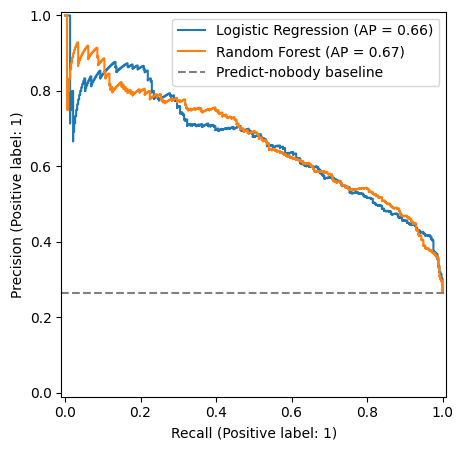

In [10]:
fig, ax = plt.subplots(figsize=(6, 5))
PrecisionRecallDisplay.from_predictions(y_test, p_lr, name="Logistic Regression", ax=ax)
PrecisionRecallDisplay.from_predictions(y_test, p_rf, name="Random Forest", ax=ax)
ax.axhline(y_test.mean(), linestyle="--", color="grey", label="Predict-nobody baseline")
ax.legend()
plt.savefig("../reports/precision_recall_curve.png", dpi=150, bbox_inches="tight")
plt.show()

In [11]:
print("Average predicted probability:", round(p_lr.mean(), 3))
print("Actual churn rate:", round(y_test.mean(), 3))

Average predicted probability: 0.407
Actual churn rate: 0.265


In [12]:
final_model = logit
X_train_final, X_test_final = X_train_lin, X_test_lin

print("raw | Brier:", round(brier_score_loss(y_test, p_lr), 4))

calibrated = {}
for method in ["sigmoid", "isotonic"]:
    c = CalibratedClassifierCV(estimator=final_model, method=method, cv=5)
    c.fit(X_train_final, y_train)
    p = c.predict_proba(X_test_final)[:, 1]
    calibrated[method] = (c, p)
    print(method, "| avg prob:", round(p.mean(), 3), "| Brier:", round(brier_score_loss(y_test, p), 4))

raw | Brier: 0.1615
sigmoid | avg prob: 0.267 | Brier: 0.1338
isotonic | avg prob: 0.268 | Brier: 0.1334


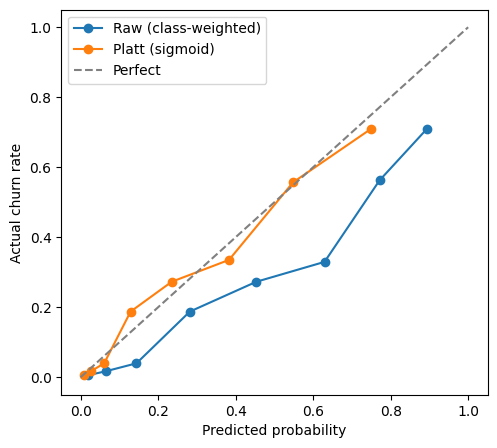

In [13]:
fig, ax = plt.subplots(figsize=(5.5, 5))
for label, p in [("Raw (class-weighted)", p_lr), ("Platt (sigmoid)", calibrated["sigmoid"][1])]:
    actual, predicted = calibration_curve(y_test, p, n_bins=8, strategy="quantile")
    ax.plot(predicted, actual, marker="o", label=label)
ax.plot([0, 1], [0, 1], "--", color="grey", label="Perfect")
ax.set_xlabel("Predicted probability")
ax.set_ylabel("Actual churn rate")
ax.legend()
plt.savefig("../reports/calibration_curve.png", dpi=150, bbox_inches="tight")
plt.show()

In [14]:
final_p = calibrated["sigmoid"][1]
ranked = pd.DataFrame({"actual": y_test.values, "prob": final_p},
                      index=y_test.index).sort_values("prob", ascending=False)

for k in [70, 140, 280]:
    top = ranked.head(k)
    print(f"Top {k}: {top['actual'].mean():.1%} actually churned | "
          f"caught {top['actual'].sum()} of {y_test.sum()} churners")

Top 70: 87.1% actually churned | caught 61 of 374 churners
Top 140: 77.9% actually churned | caught 109 of 374 churners
Top 280: 68.2% actually churned | caught 191 of 374 churners


In [15]:
os.makedirs("../models", exist_ok=True)
joblib.dump(calibrated["sigmoid"][0], "../models/churn_model.joblib")

predictions = pd.DataFrame({"churn_actual": y_test, "churn_probability": final_p},
                           index=y_test.index)
predictions.to_csv("../data/processed/test_predictions.csv")
predictions.shape

(1409, 2)